<a href="https://www.kaggle.com/code/sarraverse/train-b?scriptVersionId=306933950" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Cellule 1 — Installer les dépendances

In [1]:
!pip install transformers sentencepiece -q

# Cellule 2 — Setup et clone du repo

In [2]:
import os, sys

if not os.path.exists('/kaggle/working/sign-language-production'):
    os.system('git clone https://github.com/sarrazer24/sign-language-production.git /kaggle/working/sign-language-production')

data_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data'
print("Fichiers disponibles :", os.listdir(data_path))


Cloning into '/kaggle/working/sign-language-production'...


Fichiers disponibles : ['dataset.py', 'collate.py', 'normalize.py', 'stats.pt']


# Cellule 3 — Imports

In [3]:
import torch
import torch.nn as nn
import numpy as np
import math
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from transformers import T5EncoderModel, T5Tokenizer
import csv
from tqdm import tqdm

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_KP     = 151
POSE_DIM = N_KP * 3   # 453
BASE     = "/kaggle/input/datasets/sarraverse/how2signdataset"

print(f"Device : {DEVICE}")


Device : cuda


# Cellule 4 — Dataset et DataLoader

In [4]:
from transformers import T5Tokenizer

class How2SignDataset(Dataset):
    def __init__(self, split='train', stats=None, max_frames=500):
        assert split in ['train', 'dev', 'test']
        self.max_frames  = max_frames
        self.n_keypoints = N_KP

        with open(f"{BASE}/{split}.skels", 'r') as f:
            self.skels_lines = f.readlines()
        with open(f"{BASE}/{split}.text", 'r', encoding='utf-8') as f:
            self.text_lines = f.readlines()
        with open(f"{BASE}/{split}.files", 'r') as f:
            self.files_lines = f.readlines()

        self.tokenizer = T5Tokenizer.from_pretrained('t5-small')
        self.stats = stats

    def __len__(self):
        return len(self.skels_lines)

    def __getitem__(self, idx):
        vals     = np.array(self.skels_lines[idx].strip().split(), dtype=np.float32)
        n_frames = len(vals) // (self.n_keypoints * 3)
        poses    = vals[:n_frames * self.n_keypoints * 3].reshape(n_frames, self.n_keypoints, 3)

        if n_frames > self.max_frames:
            poses    = poses[:self.max_frames]
            n_frames = self.max_frames

        if self.stats is not None:
            mean = self.stats['mean'].numpy()
            std  = self.stats['std'].numpy()
            std  = np.where(std < 1e-6, 1.0, std)
            poses = (poses - mean) / std
            poses = np.clip(poses, -3.0, 3.0)

        poses = torch.FloatTensor(poses)

        text = self.text_lines[idx].strip()
        enc  = self.tokenizer(
            text, return_tensors='pt',
            padding=False, truncation=True, max_length=200
        )

        return {
            'poses'         : poses,
            'pose_length'   : n_frames,
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'text'          : text,
            'file_ref'      : self.files_lines[idx].strip()
        }


def collate_fn(batch):
    batch        = sorted(batch, key=lambda x: x['pose_length'], reverse=True)
    pose_lengths = torch.LongTensor([item['pose_length'] for item in batch])
    T_max        = pose_lengths[0].item()
    B            = len(batch)
    K            = batch[0]['poses'].shape[1]

    poses_padded = torch.zeros(B, T_max, K, 3)
    pose_mask    = torch.zeros(B, T_max, dtype=torch.bool)
    for i, item in enumerate(batch):
        T = item['pose_length']
        poses_padded[i, :T] = item['poses']
        pose_mask[i, :T]    = True

    input_ids = torch.nn.utils.rnn.pad_sequence(
        [item['input_ids'] for item in batch],
        batch_first=True, padding_value=0
    )
    attention_mask = torch.nn.utils.rnn.pad_sequence(
        [item['attention_mask'] for item in batch],
        batch_first=True, padding_value=0
    )

    return {
        'poses'         : poses_padded,
        'pose_mask'     : pose_mask,
        'pose_lengths'  : pose_lengths,
        'input_ids'     : input_ids,
        'attention_mask': attention_mask,
        'texts'         : [item['text'] for item in batch]
    }


# Cellule 5 — Charger stats.pt et créer les DataLoaders

In [5]:
stats_path = '/kaggle/working/sign-language-production/phase1_text_to_pose/data/stats.pt'

if os.path.exists(stats_path):
    stats = torch.load(stats_path)
    print("✅ stats.pt chargé depuis le repo")
else:
    print("⚠️ stats.pt introuvable — recalcul en cours...")
    all_poses = []
    with open(f"{BASE}/train.skels", 'r') as f:
        for i, line in enumerate(f):
            if i >= 5000:
                break
            vals    = np.array(line.strip().split(), dtype=np.float32)
            n_frames = len(vals) // (N_KP * 3)
            if n_frames == 0:
                continue
            poses = vals[:n_frames * N_KP * 3].reshape(n_frames, N_KP, 3)
            all_poses.append(poses[:100])
    all_poses = np.concatenate(all_poses, axis=0)
    stats = {
        'mean': torch.FloatTensor(all_poses.mean(axis=0)),
        'std' : torch.FloatTensor(all_poses.std(axis=0))
    }
    torch.save(stats, stats_path)
    print("✅ stats.pt recalculé et sauvegardé")

train_ds = How2SignDataset('train', stats=stats, max_frames=500)
dev_ds   = How2SignDataset('dev',   stats=stats, max_frames=500)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,
                          collate_fn=collate_fn, num_workers=2)
dev_loader   = DataLoader(dev_ds,   batch_size=16, shuffle=False,
                          collate_fn=collate_fn, num_workers=2)

print(f"Train : {len(train_ds)} samples — {len(train_loader)} batches")
print(f"Dev   : {len(dev_ds)}   samples — {len(dev_loader)}   batches")

batch = next(iter(train_loader))
print(f"Batch poses shape : {batch['poses'].shape}")
print(f"Batch texte[0]    : {batch['texts'][0][:60]}")


✅ stats.pt chargé depuis le repo


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train : 31046 samples — 1941 batches
Dev   : 1739   samples — 109   batches
Batch poses shape : torch.Size([16, 125, 151, 3])
Batch texte[0]    : "Always bring it out and make a quick stock, you just add wa


# Cellule 6 — Bloc 1 : TextEncoder

In [6]:
class TextEncoder(nn.Module):
    def __init__(self, model_name='t5-small', output_dim=512):
        super().__init__()
        self.encoder = T5EncoderModel.from_pretrained(model_name)

        for param in self.encoder.parameters():
            param.requires_grad = False
        for param in self.encoder.encoder.block[-2:].parameters():
            param.requires_grad = True

        hidden_size = self.encoder.config.d_model
        self.proj   = nn.Linear(hidden_size, output_dim) \
                      if hidden_size != output_dim else nn.Identity()

    def forward(self, input_ids, attention_mask):
        outputs       = self.encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state
        mask          = attention_mask.unsqueeze(-1).float()
        pooled        = (hidden_states * mask).sum(1) / mask.sum(1).clamp(1e-9)
        return self.proj(pooled)                            # (B, 512)


# Cellule 7 — Bloc 2 : TimestepEmbedding

In [7]:
class TimestepEmbedding(nn.Module):
    def __init__(self, dim=512):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def sinusoidal_embedding(self, timesteps):
        device = timesteps.device
        half   = self.dim // 2
        freqs  = torch.exp(
            -math.log(10000) *
            torch.arange(half, device=device) / (half - 1)
        )
        args = timesteps[:, None].float() * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

    def forward(self, timesteps):
        return self.mlp(self.sinusoidal_embedding(timesteps))  # (B, 512)


# Cellule 8 — Bloc 3 : SemanticTimestepConditioning

In [8]:
class SemanticTimestepConditioning(nn.Module):
    def __init__(self, dim=512, num_heads=8):
        super().__init__()
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim)
        )

    def forward(self, t_embd, c_embd):
        t        = t_embd.unsqueeze(1)
        c        = c_embd.unsqueeze(1)
        attn_out, _ = self.cross_attn(query=t, key=c, value=c)
        t        = self.norm1(t + attn_out)
        t        = self.norm2(t + self.ffn(t))
        return t.squeeze(1)                                    # (B, 512)


# Cellule 9 — Bloc 4 : UNet1D

In [9]:
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, cond_dim=512):
        super().__init__()
        self.conv1     = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.conv2     = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.cond_proj = nn.Linear(cond_dim, out_ch * 2)
        self.norm1     = nn.GroupNorm(8, out_ch)
        self.norm2     = nn.GroupNorm(8, out_ch)
        self.act       = nn.SiLU()
        self.res_proj  = nn.Conv1d(in_ch, out_ch, 1) \
                         if in_ch != out_ch else nn.Identity()

    def forward(self, x, z_c):
        h            = self.act(self.norm1(self.conv1(x)))
        scale, shift = self.cond_proj(z_c).chunk(2, dim=-1)
        h            = h * (1 + scale.unsqueeze(-1)) + shift.unsqueeze(-1)
        h            = self.act(self.norm2(self.conv2(h)))
        return h + self.res_proj(x)


class UNet1D(nn.Module):
    def __init__(self, pose_dim=453, cond_dim=512, base_ch=128):
        super().__init__()
        C = base_ch
        self.input_proj  = nn.Conv1d(pose_dim, C, 1)
        self.enc1        = ResBlock1D(C,     C,     cond_dim)
        self.enc2        = ResBlock1D(C,     C * 2, cond_dim)
        self.enc3        = ResBlock1D(C * 2, C * 4, cond_dim)
        self.down1       = nn.Conv1d(C,     C,     3, stride=2, padding=1)
        self.down2       = nn.Conv1d(C * 2, C * 2, 3, stride=2, padding=1)
        self.down3       = nn.Conv1d(C * 4, C * 4, 3, stride=2, padding=1)
        self.bottleneck  = ResBlock1D(C * 4, C * 4, cond_dim)
        self.dec3        = ResBlock1D(C * 8, C * 4, cond_dim)
        self.dec2        = ResBlock1D(C * 6, C * 2, cond_dim)
        self.dec1        = ResBlock1D(C * 3, C,     cond_dim)
        self.up3         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up2         = nn.ConvTranspose1d(C * 4, C * 4, 4, stride=2, padding=1)
        self.up1         = nn.ConvTranspose1d(C * 2, C * 2, 4, stride=2, padding=1)
        self.output_proj = nn.Conv1d(C, pose_dim, 1)

    def _match_size(self, x, target):
        if x.shape[2] != target.shape[2]:
            x = x[:, :, :target.shape[2]]
        return x

    def forward(self, x, z_c):
        x  = self.input_proj(x.transpose(1, 2))
        s1 = self.enc1(x,  z_c);  x = self.down1(s1)
        s2 = self.enc2(x,  z_c);  x = self.down2(s2)
        s3 = self.enc3(x,  z_c);  x = self.down3(s3)
        x  = self.bottleneck(x, z_c)
        x  = self.dec3(torch.cat([self._match_size(self.up3(x), s3), s3], dim=1), z_c)
        x  = self.dec2(torch.cat([self._match_size(self.up2(x), s2), s2], dim=1), z_c)
        x  = self.dec1(torch.cat([self._match_size(self.up1(x), s1), s1], dim=1), z_c)
        return self.output_proj(x).transpose(1, 2)


# Cellule 10 — Bloc 5 : GaussianDiffusion

> **FIX appliqué :** `sample()` accepte maintenant une fonction `z_c_fn(t_tensor) -> z_c`
> pour que le conditionneur STC reçoive le bon timestep à chaque step du débruitage.
> Avant, `z_c` était calculé une seule fois avec `t=0` figé.


In [10]:
class GaussianDiffusion(nn.Module):
    def __init__(self, model, T=100):
        super().__init__()
        self.model = model
        self.T     = T

        betas          = self._cosine_schedule(T)
        alphas         = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        self.register_buffer('betas',          betas)
        self.register_buffer('alphas',         alphas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('sqrt_acp',       torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus', torch.sqrt(1 - alphas_cumprod))

    def _cosine_schedule(self, T, s=0.008):
        steps = torch.arange(T + 1, dtype=torch.float32)
        f     = torch.cos((steps / T + s) / (1 + s) * math.pi / 2) ** 2
        betas = 1 - f[1:] / f[:-1]
        return torch.clamp(betas, 0.0001, 0.9999)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        s  = self.sqrt_acp[t][:, None, None]
        sm = self.sqrt_one_minus[t][:, None, None]
        return s * x0 + sm * noise, noise

    def compute_loss(self, x0, z_c, pose_mask):
        B          = x0.shape[0]
        t          = torch.randint(0, self.T, (B,), device=x0.device)
        x_t, noise = self.q_sample(x0, t)
        noise_pred = self.model(x_t, z_c)
        mask       = pose_mask.unsqueeze(-1).float()
        return ((noise_pred - noise) ** 2 * mask).sum() / mask.sum()

    @torch.no_grad()
    def p_sample(self, x_t, t_val, z_c):
        t        = torch.full((x_t.shape[0],), t_val,
                              device=x_t.device, dtype=torch.long)
        beta     = self.betas[t][:, None, None]
        alpha    = self.alphas[t][:, None, None]
        alpha_cp = self.alphas_cumprod[t][:, None, None]
        pred     = self.model(x_t, z_c)

        clip_val = 1.0 + 2.0 * (t_val / self.T)
        pred     = torch.clamp(pred, -clip_val, clip_val)

        coef = beta / torch.sqrt(1 - alpha_cp)
        mean = (1 / torch.sqrt(alpha)) * (x_t - coef * pred)
        mean = torch.clamp(mean, -3.0, 3.0)

        if t_val > 0:
            mean = mean + torch.sqrt(beta) * torch.randn_like(x_t)

        return mean

    @torch.no_grad()
    def sample(self, z_c_fn, n_frames, batch_size, device):
        """
        FIX : z_c_fn est une fonction (t_tensor: LongTensor) -> z_c (B, 512).
        Le conditionneur STC est appelé à chaque step avec le bon timestep,
        ce qui lui permet d'adapter la pondération texte selon le niveau de bruit.
        """
        x = torch.randn(batch_size, n_frames, POSE_DIM, device=device)
        for t_val in reversed(range(self.T)):
            t_tensor = torch.full((batch_size,), t_val, device=device, dtype=torch.long)
            z_c      = z_c_fn(t_tensor)         # z_c recalculé à chaque step ✅
            x        = self.p_sample(x, t_val, z_c)
        return x


# Cellule 11 — Modèle complet ApproachB

> **FIX 1 :** `PoseEncoder` supprimé. Il causait un data leakage à l'entraînement
> (le modèle voyait les GT poses via `c_fused = c_embd + pose_cond`) mais était absent
> à l'inférence → distribution mismatch → MPJPE artificiellement énorme.
>
> **FIX 2 :** `generate()` utilise maintenant `diffusion.sample(z_c_fn, ...)` où
> `z_c_fn` recalcule le conditionneur STC avec le bon timestep à chaque step.


In [11]:
class ApproachB(nn.Module):
    def __init__(self, T=100, use_contribution=True):
        super().__init__()
        self.use_contribution = use_contribution
        self.text_encoder     = TextEncoder()
        self.timestep_emb     = TimestepEmbedding(dim=512)
        self.semantic_cond    = SemanticTimestepConditioning(dim=512)
        self.unet             = UNet1D(pose_dim=POSE_DIM, base_ch=96)
        self.diffusion        = GaussianDiffusion(self.unet, T=T)
        self.naive_proj       = nn.Linear(512, 512)

    def get_condition(self, t_embd, c_embd):
        """Retourne z_c selon la version (avec/sans contribution)."""
        if self.use_contribution:
            return self.semantic_cond(t_embd, c_embd)
        else:
            return self.naive_proj(t_embd + c_embd)

    def forward(self, batch):
        """
        Training forward pass.
        Le timestep t est tiré aléatoirement — cohérent avec l'entraînement DDPM.
        Pas de PoseEncoder : la condition est texte-only (comme à l'inférence).
        """
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        poses          = batch['poses'].to(DEVICE)
        pose_mask      = batch['pose_mask'].to(DEVICE)

        B, T, K, _ = poses.shape
        x0         = poses.reshape(B, T, K * 3)           # (B, T, 453)

        # Encoder le texte (condition fixe)
        c_embd = self.text_encoder(input_ids, attention_mask)  # (B, 512)

        # Timestep aléatoire
        t      = torch.randint(0, self.diffusion.T, (B,), device=DEVICE)
        t_embd = self.timestep_emb(t)                          # (B, 512)

        # Conditionneur STC avec le bon timestep
        z_c = self.get_condition(t_embd, c_embd)               # (B, 512)

        return self.diffusion.compute_loss(x0, z_c, pose_mask)

    @torch.no_grad()
    def generate(self, input_ids, attention_mask, n_frames=55):
        """
        Inférence : z_c_fn recalcule le conditionneur à chaque step du débruitage
        avec le vrai timestep courant, exactement comme à l'entraînement.
        """
        self.eval()
        B      = input_ids.shape[0]
        c_embd = self.text_encoder(input_ids, attention_mask)  # (B, 512)

        def z_c_fn(t_tensor):
            """Recalcule z_c pour le timestep courant de la reverse diffusion."""
            t_embd = self.timestep_emb(t_tensor)
            return self.get_condition(t_embd, c_embd)

        poses = self.diffusion.sample(z_c_fn, n_frames, batch_size=B, device=DEVICE)
        return poses.reshape(B, n_frames, N_KP, 3)


# ── Test forward pass ────────────────────────────────────────
model_test = ApproachB(T=100, use_contribution=True).to(DEVICE)
batch_test = next(iter(train_loader))
loss_test  = model_test(batch_test)
print(f"✅ Forward pass OK — Loss test : {loss_test.item():.4f}")
del model_test


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

✅ Forward pass OK — Loss test : 545.1191


# Cellule 12 — Fonctions d'entraînement et d'évaluation

In [12]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = model(batch)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for batch in tqdm(loader, desc="Eval", leave=False):
        with torch.cuda.amp.autocast():
            loss = model(batch)
        total_loss += loss.item()
    return total_loss / len(loader)


# Cellule 13 — Lancement entraînement

In [13]:
def run_training(use_contribution=True, n_epochs_max=150, lr=3e-5,
                 tag="with_contrib", patience=10, min_delta=0.01):
    model     = ApproachB(T=100, use_contribution=use_contribution).to(DEVICE)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-2
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs_max, eta_min=1e-6
    )
    scaler         = torch.cuda.amp.GradScaler()
    history        = {'train': [], 'dev': []}
    best_dev_loss  = float('inf')
    epochs_no_impr = 0
    stopped_epoch  = n_epochs_max

    print(f"\n{'='*55}")
    print(f"Entraînement — {tag}")
    print(f"Max epochs : {n_epochs_max} | Patience : {patience} | "
          f"Min delta : {min_delta} | LR : {lr}")
    print(f"Paramètres entraînables : "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"{'='*55}\n")

    for epoch in range(1, n_epochs_max + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        dev_loss   = evaluate(model, dev_loader)
        scheduler.step()

        history['train'].append(train_loss)
        history['dev'].append(dev_loss)

        if dev_loss < best_dev_loss - min_delta:
            best_dev_loss  = dev_loss
            epochs_no_impr = 0
            torch.save(model.state_dict(),
                       f'/kaggle/working/best_{tag}.pt')
            print(f"Epoch {epoch:3d}/{n_epochs_max} | "
                  f"Train: {train_loss:.4f} | Dev: {dev_loss:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                  f"✅ Meilleur checkpoint")
        else:
            epochs_no_impr += 1
            print(f"Epoch {epoch:3d}/{n_epochs_max} | "
                  f"Train: {train_loss:.4f} | Dev: {dev_loss:.4f} | "
                  f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                  f"No impr: {epochs_no_impr}/{patience}")

        if epochs_no_impr >= patience:
            stopped_epoch = epoch
            print(f"\n⏹️  Early stopping à l'epoch {epoch} — "
                  f"pas d'amélioration depuis {patience} epochs")
            print(f"   Meilleure dev loss : {best_dev_loss:.4f}")
            break
    else:
        print(f"\n⚠️  Max epochs ({n_epochs_max}) atteint")
        print(f"   Meilleure dev loss : {best_dev_loss:.4f}")

    print(f"\n{'='*55}")
    print(f"Arrêt à l'epoch {stopped_epoch}/{n_epochs_max}")
    print(f"Meilleure dev loss : {best_dev_loss:.4f}")
    print(f"{'='*55}\n")

    model.load_state_dict(
        torch.load(f'/kaggle/working/best_{tag}.pt', map_location=DEVICE)
    )
    return model, history


model_with,    history_with    = run_training(use_contribution=True,
                                               n_epochs_max=150,
                                               lr=3e-5,
                                               tag="with_contrib",
                                               patience=10,
                                               min_delta=0.01)

model_without, history_without = run_training(use_contribution=False,
                                               n_epochs_max=150,
                                               lr=3e-5,
                                               tag="without_contrib",
                                               patience=10,
                                               min_delta=0.01)


Loading weights:   0%|          | 0/51 [00:00<?, ?it/s]

/tmp/ipykernel_24/2853398849.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler()



Entraînement — with_contrib
Max epochs : 150 | Patience : 10 | Min delta : 0.01 | LR : 3e-05
Paramètres entraînables : 17,665,317



Train:   0%|          | 0/1941 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Eval:   0%|          | 0/109 [00:00<?, ?it/s]/tmp/ipykernel_24/4046232825.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/150 | Train: 427.1970 | Dev: 402.9344 | LR: 3.00e-05 | ✅ Meilleur checkpoint


...

Epoch  30/150 | Train: 360.6721 | Dev: 361.6419 | LR: 2.72e-05 | No impr: 6/10


Epoch  31/150 | Train: 360.5328 | Dev: 360.9427 | LR: 2.70e-05 | No impr: 7/10


Epoch  32/150 | Train: 360.4595 | Dev: 361.1410 | LR: 2.69e-05 | No impr: 8/10


Epoch  33/150 | Train: 360.4383 | Dev: 361.5000 | LR: 2.67e-05 | No impr: 9/10


Epoch  34/150 | Train: 360.2967 | Dev: 361.1107 | LR: 2.65e-05 | No impr: 10/10

⏹️  Early stopping à l'epoch 34 — pas d'amélioration depuis 10 epochs
   Meilleure dev loss : 360.9475

Arrêt à l'epoch 34/150
Meilleure dev loss : 360.9475



# Cellule 14 — Courbe de convergence (log scale)

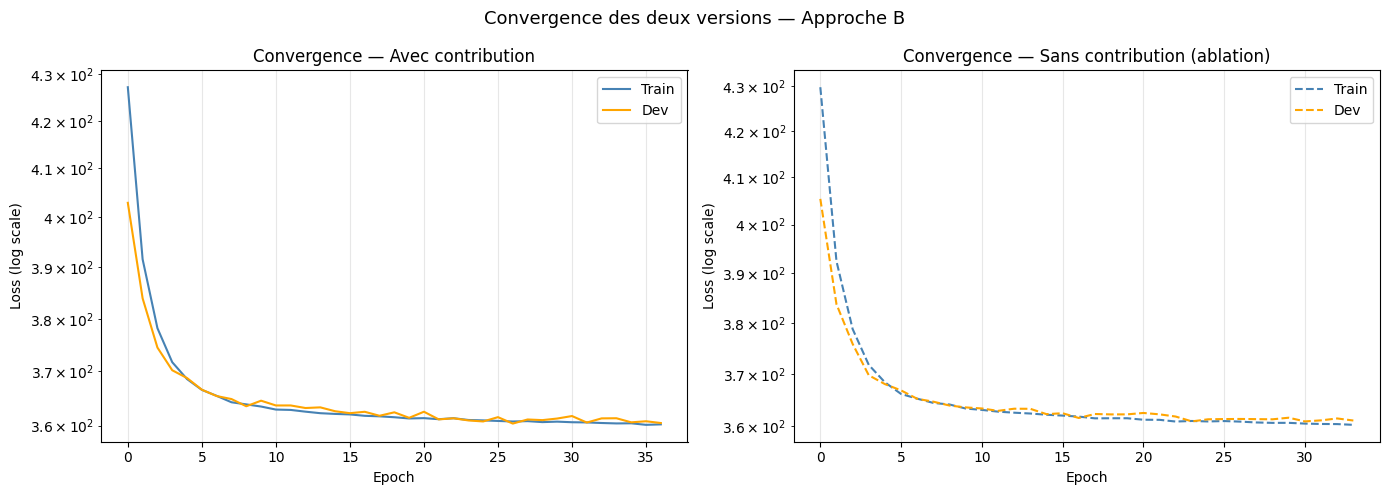

Loss train epoch 33 : 360.4747
Loss train epoch 37   : 360.2241
⚠️  La loss descend encore → le modèle n'a pas convergé, augmenter n_epochs


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_with['train'], label='Train', color='steelblue')
axes[0].plot(history_with['dev'],   label='Dev',   color='orange')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Convergence — Avec contribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_without['train'], label='Train', color='steelblue', linestyle='--')
axes[1].plot(history_without['dev'],   label='Dev',   color='orange',    linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Convergence — Sans contribution (ablation)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Convergence des deux versions — Approche B', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/convergence_approach_b.png', dpi=150)
plt.show()

last_train_with = history_with['train'][-1]
prev_train_with = history_with['train'][-5]
still_decreasing = last_train_with < prev_train_with

print(f"Loss train epoch {len(history_with['train'])-4} : {prev_train_with:.4f}")
print(f"Loss train epoch {len(history_with['train'])}   : {last_train_with:.4f}")
if still_decreasing:
    print("⚠️  La loss descend encore → le modèle n'a pas convergé, augmenter n_epochs")
else:
    print("✅  La loss a convergé")


# Cellule 15 — Courbes de loss comparatives

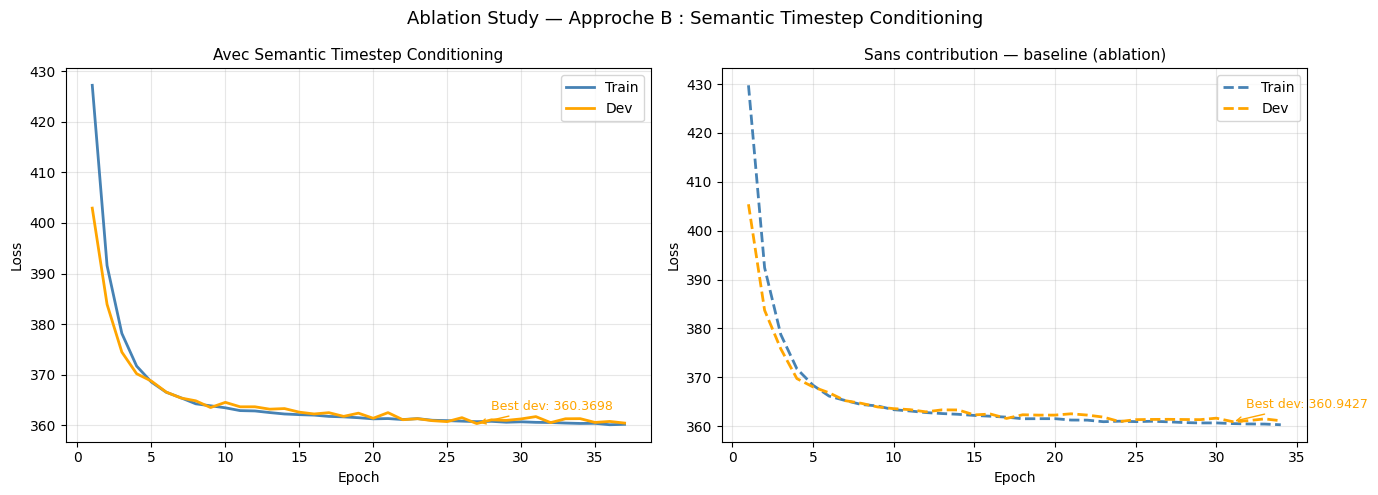

Modèle AVEC  : convergé à l'epoch 37
Modèle SANS  : convergé à l'epoch 34

Meilleure dev loss AVEC : 360.3698
Meilleure dev loss SANS : 360.9427
Gain de notre contribution : +0.5729


In [15]:
epochs_with    = range(1, len(history_with['train']) + 1)
epochs_without = range(1, len(history_without['train']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_with, history_with['train'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(epochs_with, history_with['dev'],   label='Dev',   color='orange',    linewidth=2)
axes[0].set_title('Avec Semantic Timestep Conditioning', fontsize=11)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].annotate(f"Best dev: {min(history_with['dev']):.4f}",
                 xy=(np.argmin(history_with['dev']) + 1, min(history_with['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

axes[1].plot(epochs_without, history_without['train'], label='Train', color='steelblue',
             linewidth=2, linestyle='--')
axes[1].plot(epochs_without, history_without['dev'],   label='Dev',   color='orange',
             linewidth=2, linestyle='--')
axes[1].set_title('Sans contribution — baseline (ablation)', fontsize=11)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].annotate(f"Best dev: {min(history_without['dev']):.4f}",
                 xy=(np.argmin(history_without['dev']) + 1, min(history_without['dev'])),
                 xytext=(10, 10), textcoords='offset points',
                 fontsize=9, color='orange',
                 arrowprops=dict(arrowstyle='->', color='orange'))

plt.suptitle('Ablation Study — Approche B : Semantic Timestep Conditioning', fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/loss_curves_approach_b.png', dpi=150)
plt.show()

print(f"Modèle AVEC  : convergé à l'epoch {len(history_with['train'])}")
print(f"Modèle SANS  : convergé à l'epoch {len(history_without['train'])}")
print(f"\nMeilleure dev loss AVEC : {min(history_with['dev']):.4f}")
print(f"Meilleure dev loss SANS : {min(history_without['dev']):.4f}")
print(f"Gain de notre contribution : "
      f"{min(history_without['dev']) - min(history_with['dev']):+.4f}")


# Cellule 16 — Vérification des plages de valeurs

In [16]:
batch = next(iter(dev_loader))
gt    = batch['poses']   # normalisé ∈ [-3, 3]

input_ids      = batch['input_ids'].to(DEVICE)
attention_mask = batch['attention_mask'].to(DEVICE)
n_frames       = int(batch['pose_lengths'].float().mean().item())

with torch.no_grad():
    pred = model_with.generate(input_ids, attention_mask, n_frames=n_frames)

print("Espace normalisé :")
print(f"  GT    — min: {gt.min():.4f}, max: {gt.max():.4f}, mean: {gt.mean():.4f}")
print(f"  Pred  — min: {pred.min():.4f}, max: {pred.max():.4f}, mean: {pred.mean():.4f}")

# Dénormalisation pour vérification visuelle
mean_np = stats['mean'].numpy()   # (151, 3)
std_np  = stats['std'].numpy()    # (151, 3)

gt_np   = gt.numpy()              # (B, T, 151, 3) normalisé
pred_np = pred.cpu().numpy()      # (B, n_frames, 151, 3) normalisé

gt_denorm   = gt_np   * std_np + mean_np
pred_denorm = pred_np * std_np + mean_np

print("\nEspace original (dénormalisé) :")
print(f"  GT    — min: {gt_denorm.min():.4f}, max: {gt_denorm.max():.4f}")
print(f"  Pred  — min: {pred_denorm.min():.4f}, max: {pred_denorm.max():.4f}")


Espace normalisé :
  GT    — min: -3.0000, max: 3.0000, mean: 0.0031
  Pred  — min: -3.0000, max: 3.0000, mean: 0.0055

Espace original (dénormalisé) :
  GT    — min: -0.3301, max: 1.0000
  Pred  — min: -0.3832, max: 1.3098


# Cellule 17 — MPJPE (corrigé)

> **FIX 3 :** MPJPE calculé après **dénormalisation** des poses.
> Avant, il était calculé en espace normalisé (valeurs ∈ [-3, 3]),
> ce qui donnait des valeurs sans interprétation physique.
>
> **FIX 4 :** Génération avec la **vraie longueur de chaque séquence** (sample par sample),
> au lieu de la moyenne du batch — évite les comparaisons GT/pred sur des longueurs incohérentes.


In [17]:
@torch.no_grad()
def compute_mpjpe(model, loader, stats, n_samples=200):
    """
    MPJPE en espace dénormalisé, avec la vraie longueur par séquence.
    Retourne la moyenne en unités de coordonnées originales.
    """
    model.eval()
    mean_t = stats['mean'].to(DEVICE)   # (151, 3)
    std_t  = stats['std'].to(DEVICE)    # (151, 3)

    scores = []
    count  = 0

    for batch in tqdm(loader, desc="MPJPE", leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        gt_poses       = batch['poses'].to(DEVICE)     # (B, T_max, 151, 3) normalisé
        pose_lengths   = batch['pose_lengths']         # (B,)
        B              = gt_poses.shape[0]

        for i in range(B):
            L           = pose_lengths[i].item()
            # Générer avec la vraie longueur de cette séquence
            pred_i      = model.generate(
                input_ids[i:i+1], attention_mask[i:i+1], n_frames=L
            )                                          # (1, L, 151, 3) normalisé

            # Dénormaliser les deux
            gt_i        = gt_poses[i, :L]              # (L, 151, 3)
            gt_denorm   = gt_i   * std_t + mean_t
            pred_denorm = pred_i[0] * std_t + mean_t  # (L, 151, 3)

            # Distance euclidienne par keypoint, moyennée sur frames et keypoints
            dist        = torch.norm(pred_denorm - gt_denorm, dim=-1)  # (L, 151)
            scores.append(dist.mean().item())

        count += B
        if count >= n_samples:
            break

    return float(np.mean(scores))


mpjpe_with    = compute_mpjpe(model_with,    dev_loader, stats)
mpjpe_without = compute_mpjpe(model_without, dev_loader, stats)
print(f"MPJPE AVEC contribution : {mpjpe_with:.4f}  (unités coord. originales)")
print(f"MPJPE SANS contribution : {mpjpe_without:.4f}  (unités coord. originales)")
print(f"Gain                    : {mpjpe_without - mpjpe_with:+.4f}")


MPJPE AVEC contribution : 0.2276  (unités coord. originales)
MPJPE SANS contribution : 0.2279  (unités coord. originales)
Gain                    : +0.0003


# Cellule 18 — Visualisation squelettes connectés

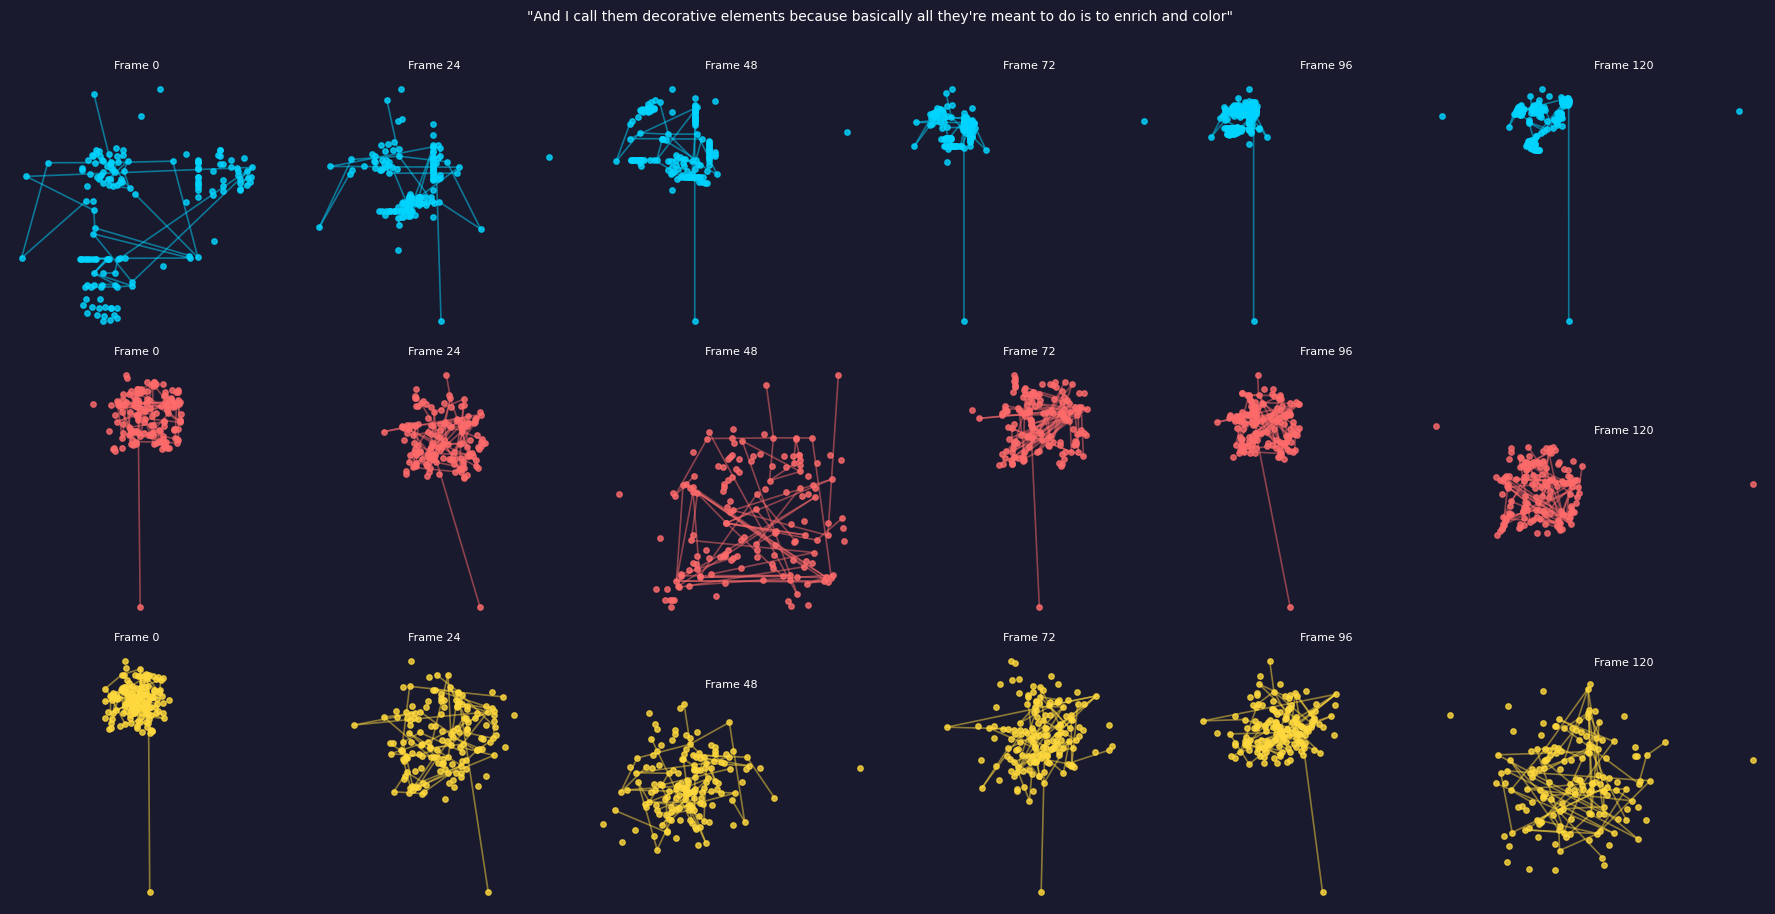

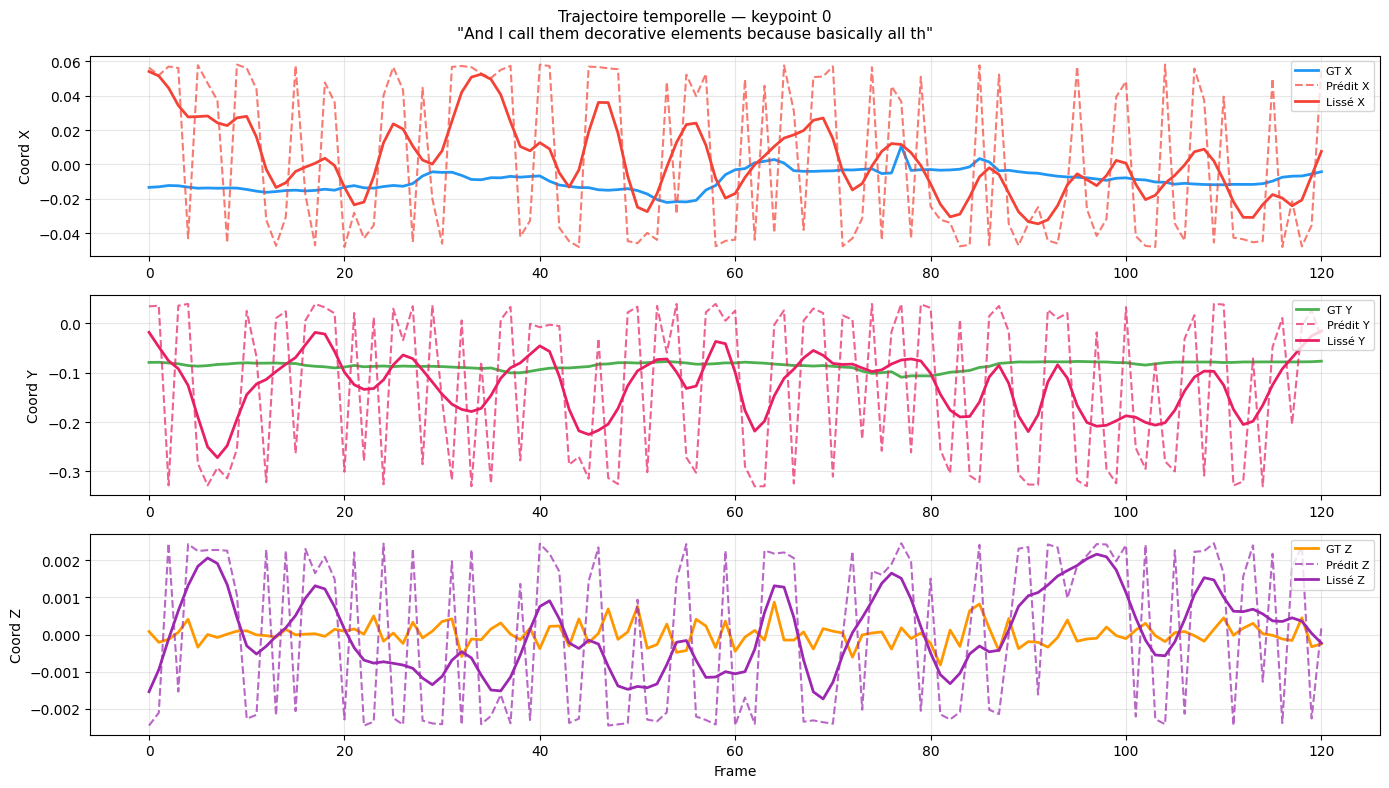

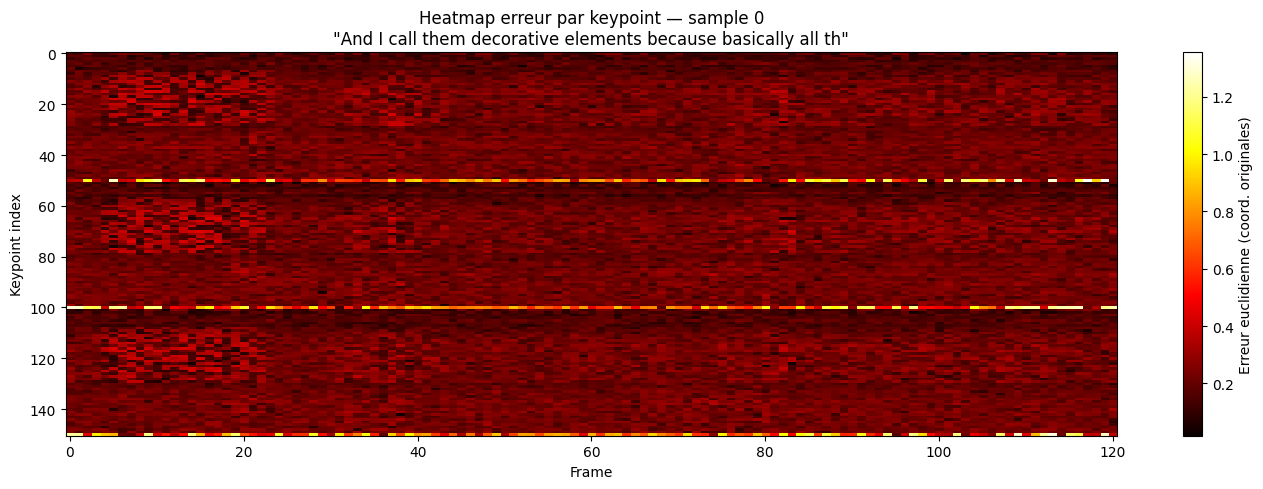

Séquence    : 121 frames
MPJPE brut  : 0.2234  (unités coord. originales)
MPJPE lissé : 0.1084
Keypoint le plus erroné : index 100 (erreur moy = 0.7536)


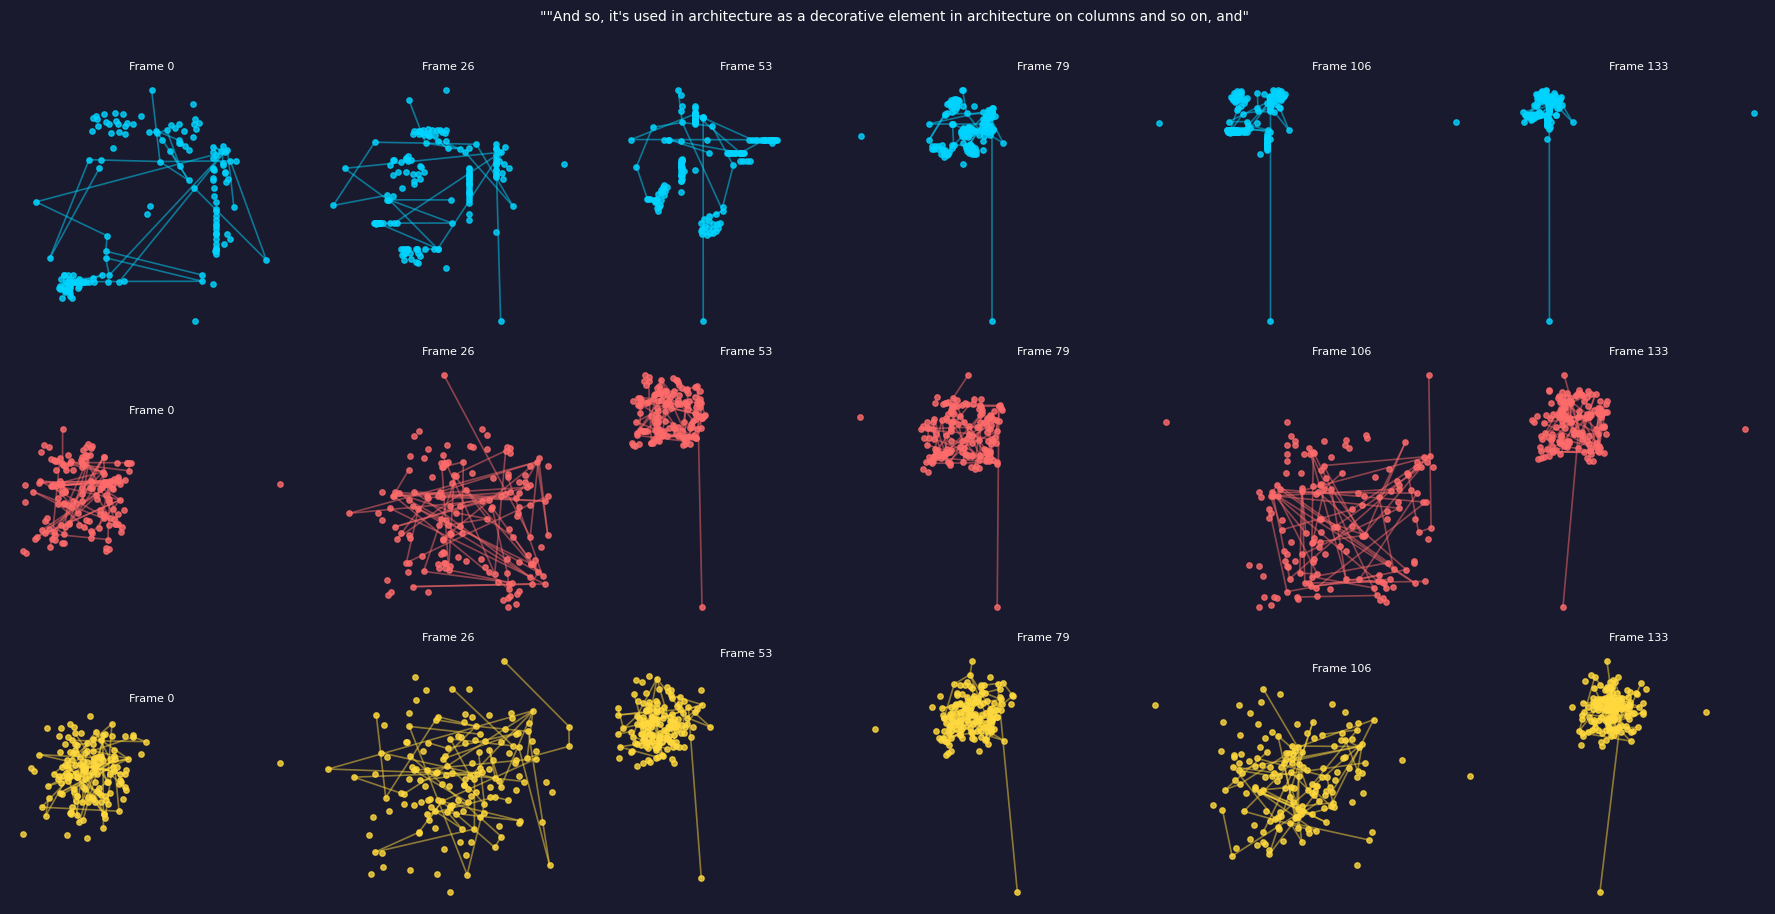

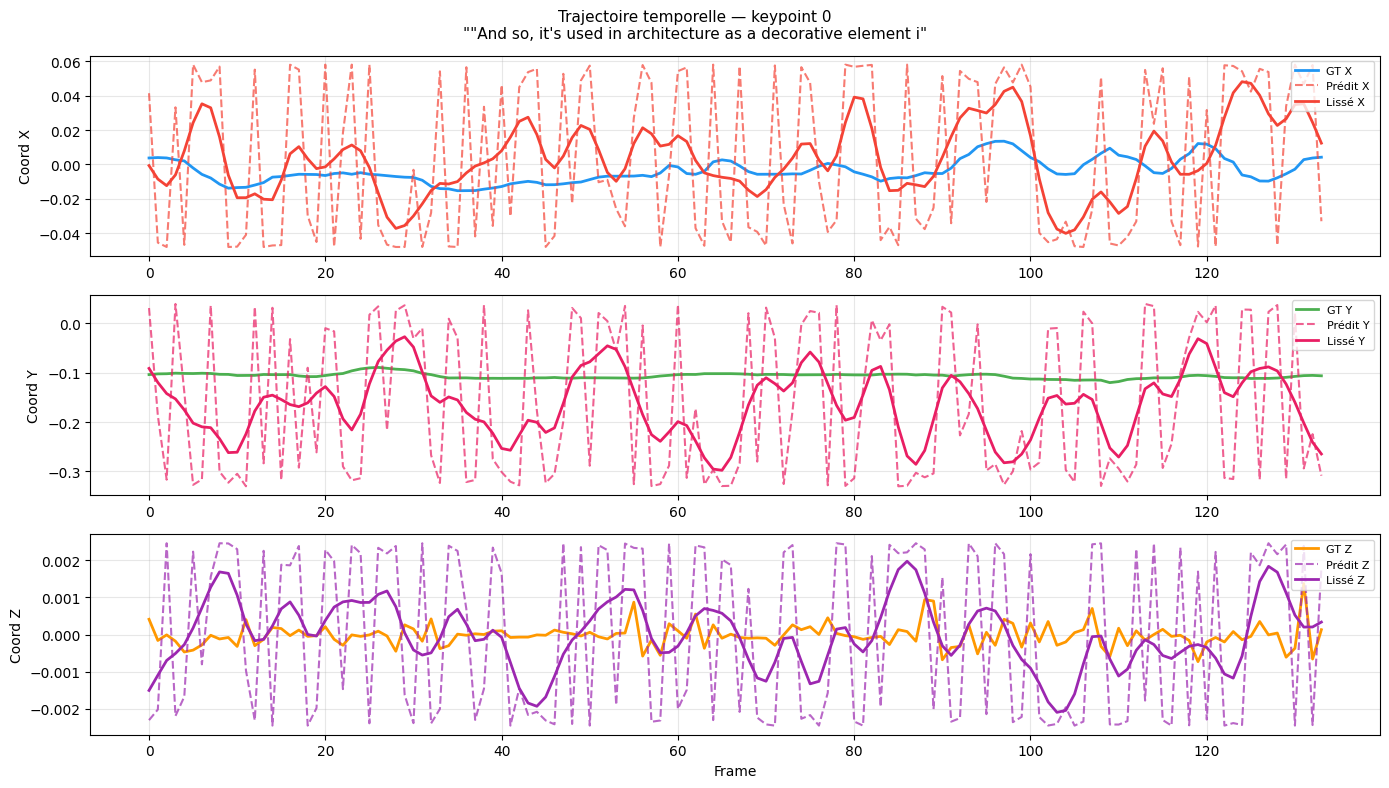

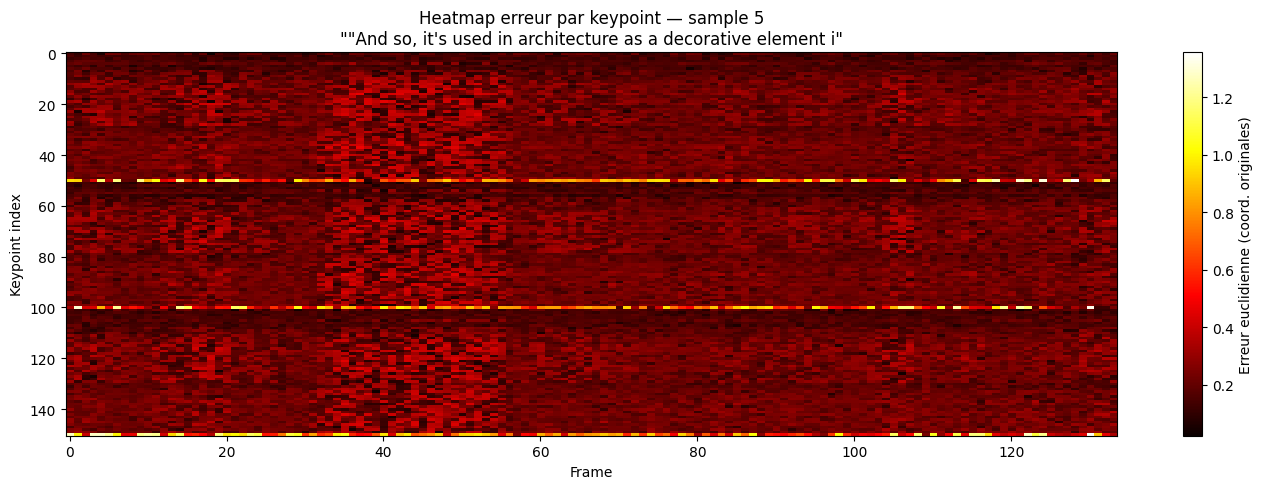

Séquence    : 134 frames
MPJPE brut  : 0.2281  (unités coord. originales)
MPJPE lissé : 0.1198
Keypoint le plus erroné : index 150 (erreur moy = 0.7319)


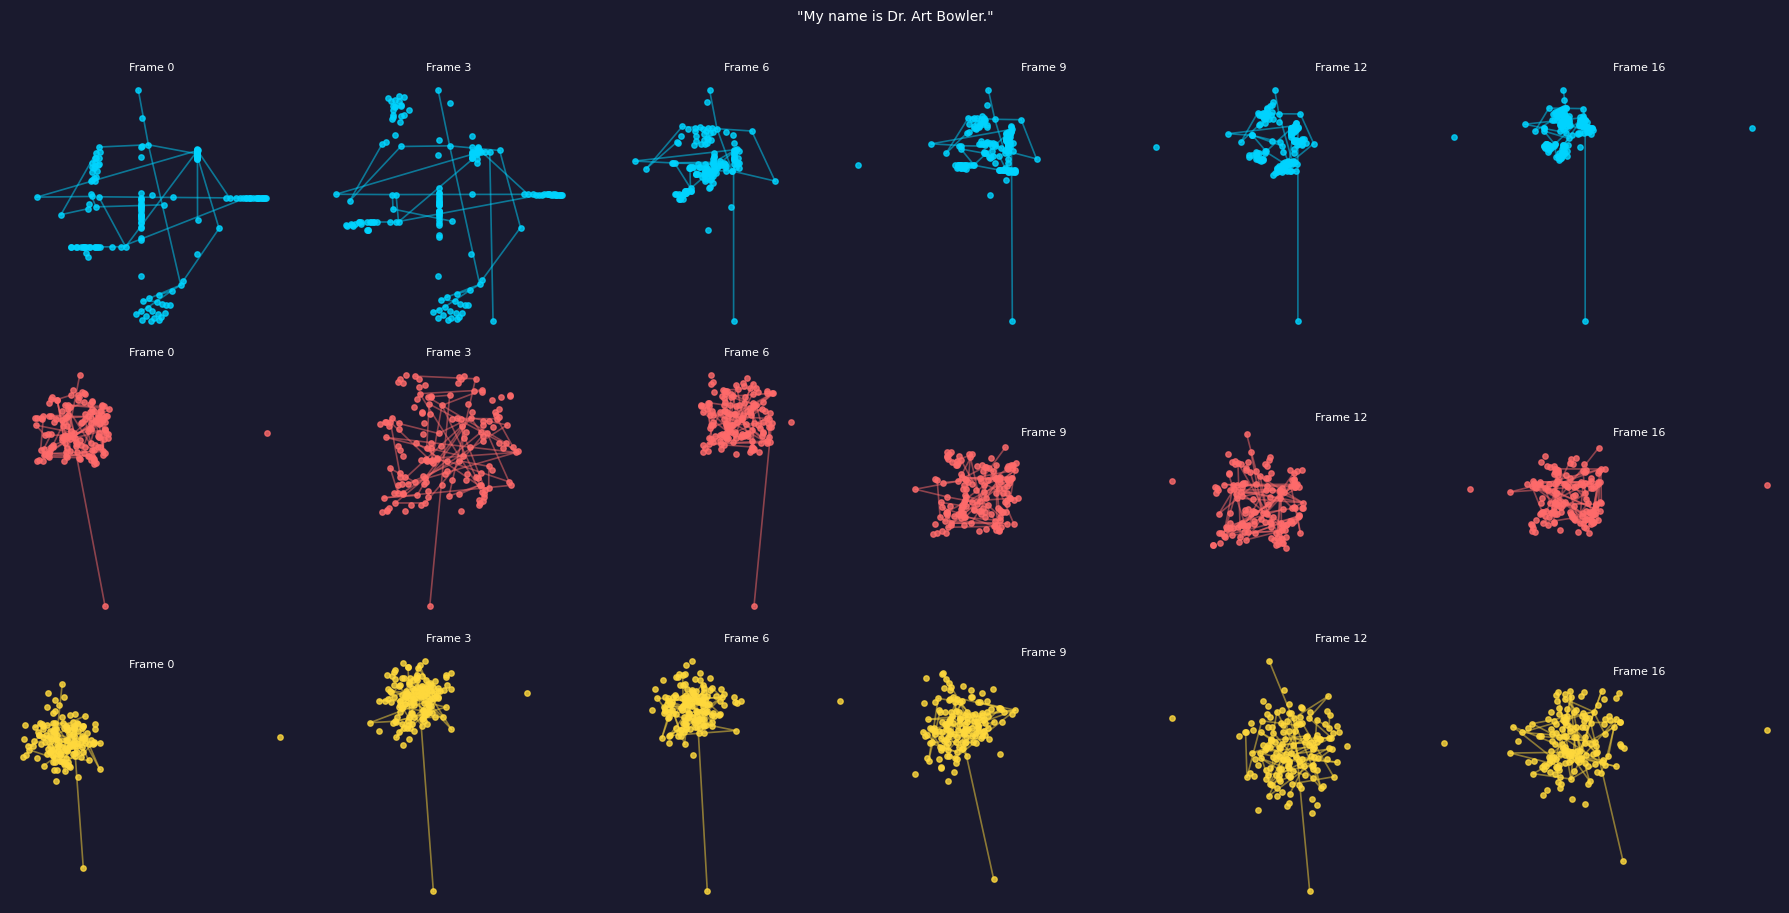

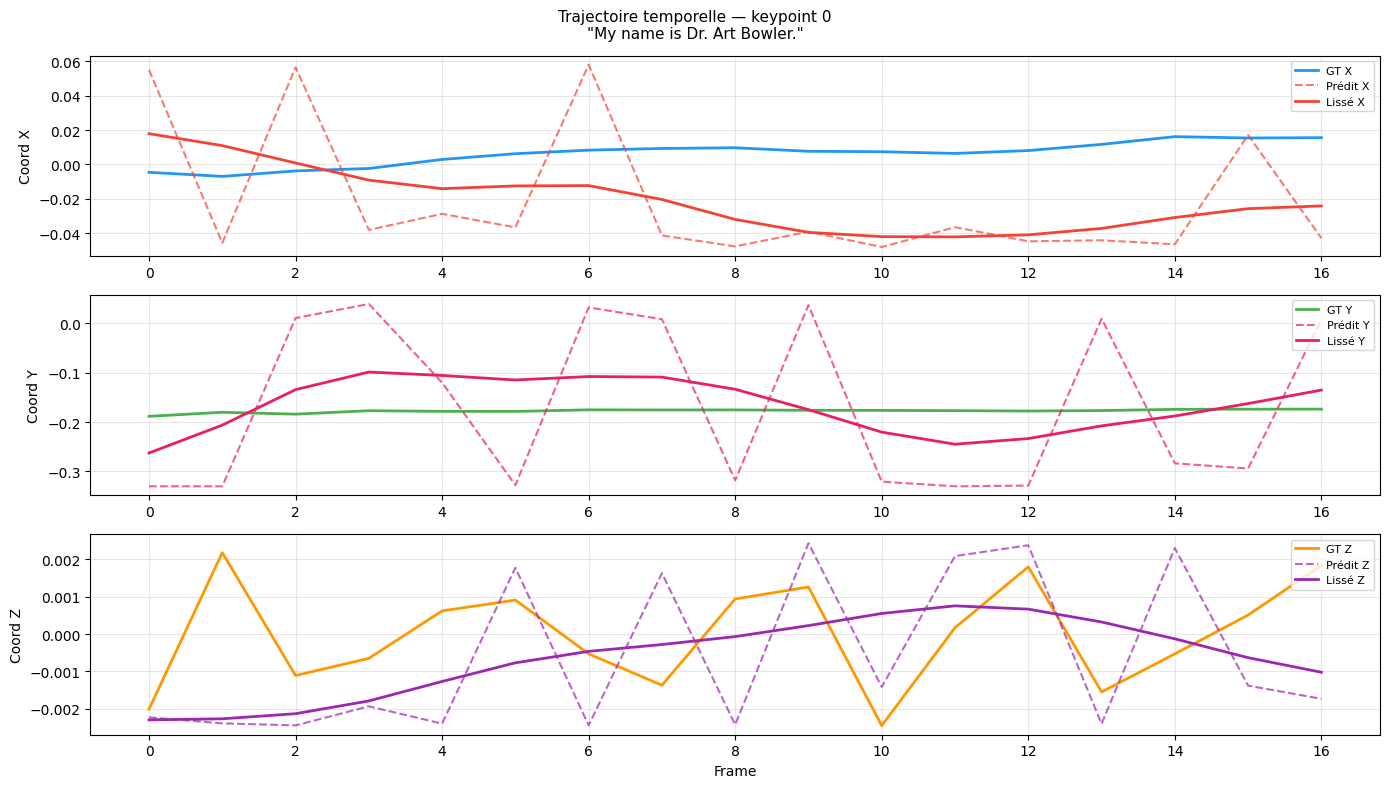

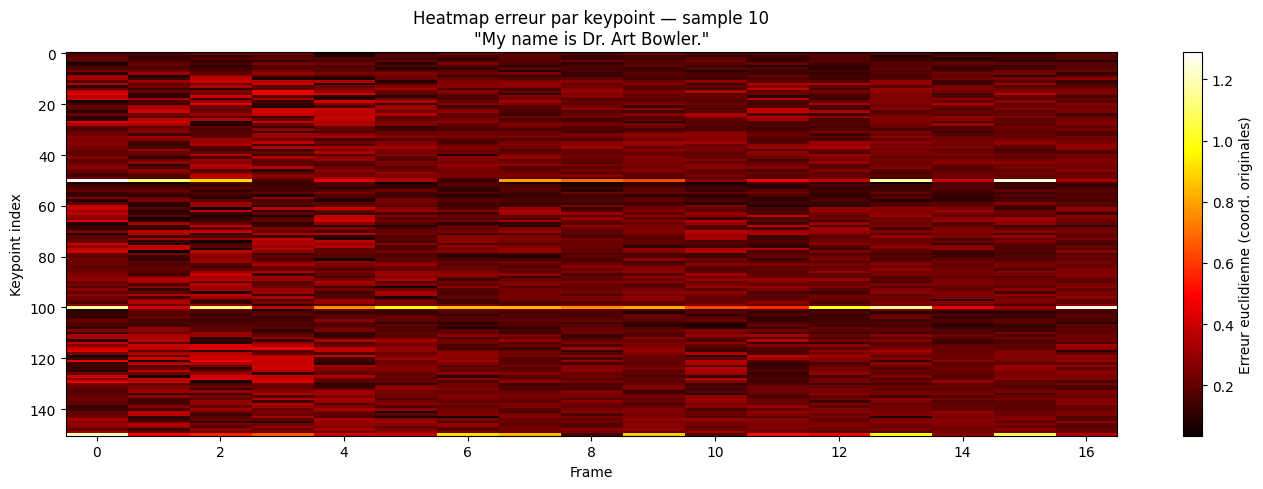

Séquence    : 17 frames
MPJPE brut  : 0.2242  (unités coord. originales)
MPJPE lissé : 0.1215
Keypoint le plus erroné : index 100 (erreur moy = 0.7899)


In [18]:
from scipy.ndimage import gaussian_filter1d

BODY_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),
    (1, 5), (5, 6), (6, 7),
    (1, 8), (8, 9), (9, 10),
    (8, 11), (11, 12), (12, 13),
    (9, 14), (14, 15), (15, 16),
    (92, 93), (93, 94), (94, 95), (95, 96),
    (92, 97), (97, 98), (98, 99), (99, 100),
    (92, 101), (101, 102), (102, 103), (103, 104),
    (92, 105), (105, 106), (106, 107), (107, 108),
    (92, 109), (109, 110), (110, 111), (111, 112),
    (113, 114), (114, 115), (115, 116), (116, 117),
    (113, 118), (118, 119), (119, 120), (120, 121),
    (113, 122), (122, 123), (123, 124), (124, 125),
    (113, 126), (126, 127), (127, 128), (128, 129),
    (113, 130), (130, 131), (131, 132), (132, 133),
]

def smooth_poses(poses, sigma=1.5):
    smoothed = np.copy(poses)
    for kp in range(poses.shape[1]):
        for coord in range(poses.shape[2]):
            smoothed[:, kp, coord] = gaussian_filter1d(
                poses[:, kp, coord], sigma=sigma
            )
    return smoothed


def plot_skeleton_connected(ax, frame, color='steelblue', alpha=0.8):
    ax.scatter(frame[:, 0], -frame[:, 1],
               s=15, c=color, alpha=alpha, zorder=3)
    for (i, j) in BODY_CONNECTIONS:
        if i < len(frame) and j < len(frame):
            ax.plot([frame[i, 0], frame[j, 0]],
                    [-frame[i, 1], -frame[j, 1]],
                    c=color, alpha=0.5, linewidth=1.2, zorder=2)
    ax.axis('off')
    ax.set_aspect('equal')


@torch.no_grad()
def visualize_full(model, dataset, stats, idx=0):
    model.eval()
    mean_np = stats['mean'].numpy()   # (151, 3)
    std_np  = stats['std'].numpy()    # (151, 3)

    sample         = dataset[idx]
    input_ids      = sample['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = sample['attention_mask'].unsqueeze(0).to(DEVICE)
    gt_norm        = sample['poses'].numpy()       # (T, 151, 3) normalisé
    text           = sample['text']
    n_frames       = gt_norm.shape[0]

    pred_norm      = model.generate(input_ids, attention_mask,
                                    n_frames=n_frames)[0].cpu().numpy()  # normalisé

    # Dénormaliser pour la visualisation
    gt_poses   = gt_norm   * std_np + mean_np
    pred_poses = pred_norm * std_np + mean_np
    pred_smoothed = smooth_poses(pred_poses, sigma=1.5)

    n_show  = 6
    indices = np.linspace(0, min(len(gt_poses), len(pred_poses)) - 1,
                          n_show, dtype=int)

    fig, axes = plt.subplots(3, n_show, figsize=(18, 9), facecolor='#1a1a2e')
    fig.suptitle(f'\"{text[:100]}\"', fontsize=10, color='white', y=1.01)

    for col, fi in enumerate(indices):
        for row, (poses, color, label) in enumerate([
            (gt_poses,      '#00d4ff', 'Ground Truth'),
            (pred_poses,    '#ff6b6b', 'Généré (brut)'),
            (pred_smoothed, '#ffd93d', 'Généré (lissé)')
        ]):
            axes[row, col].set_facecolor('#1a1a2e')
            plot_skeleton_connected(axes[row, col], poses[fi], color=color)
            axes[row, col].set_title(f'Frame {fi}', fontsize=8, color='white')
            if col == 0:
                axes[row, col].set_ylabel(label, fontsize=10,
                                           color=color, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'/kaggle/working/viz_full_{idx}.png',
                dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
    plt.show()

    # Trajectoire temporelle
    fig, axes2 = plt.subplots(3, 1, figsize=(14, 8))
    fig.suptitle(f'Trajectoire temporelle — keypoint 0\n\"{text[:60]}\"', fontsize=11)
    coords      = ['X', 'Y', 'Z']
    colors_gt   = ['#2196F3', '#4CAF50', '#FF9800']
    colors_pred = ['#F44336', '#E91E63', '#9C27B0']
    for coord_idx in range(3):
        ax = axes2[coord_idx]
        ax.plot(gt_poses[:, 0, coord_idx],     color=colors_gt[coord_idx],
                label=f'GT {coords[coord_idx]}', linewidth=2)
        ax.plot(pred_poses[:, 0, coord_idx],   color=colors_pred[coord_idx],
                label=f'Prédit {coords[coord_idx]}', linewidth=1.5, linestyle='--', alpha=0.7)
        ax.plot(pred_smoothed[:, 0, coord_idx],color=colors_pred[coord_idx],
                label=f'Lissé {coords[coord_idx]}', linewidth=2)
        ax.set_ylabel(f'Coord {coords[coord_idx]}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)
    axes2[-1].set_xlabel('Frame')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/trajectory_{idx}.png', dpi=150)
    plt.show()

    # Heatmap erreur
    min_T  = min(len(gt_poses), len(pred_poses))
    errors = np.linalg.norm(pred_poses[:min_T] - gt_poses[:min_T], axis=-1)  # (T, 151)
    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(errors.T, aspect='auto', cmap='hot', interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Erreur euclidienne (coord. originales)')
    ax.set_xlabel('Frame')
    ax.set_ylabel('Keypoint index')
    ax.set_title(f'Heatmap erreur par keypoint — sample {idx}\n\"{text[:60]}\"')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/heatmap_{idx}.png', dpi=150)
    plt.show()

    print(f"Séquence    : {n_frames} frames")
    print(f"MPJPE brut  : {errors.mean():.4f}  (unités coord. originales)")
    print(f"MPJPE lissé : {np.linalg.norm(pred_smoothed[:min_T] - gt_poses[:min_T], axis=-1).mean():.4f}")
    print(f"Keypoint le plus erroné : index {errors.mean(axis=0).argmax()} "
          f"(erreur moy = {errors.mean(axis=0).max():.4f})")


for idx in [0, 5, 10]:
    visualize_full(model_with, train_ds, stats, idx=idx)


# Cellule 19 — Sauvegarder résultats et push

In [19]:
import os, csv, json

output_dir = '/kaggle/working/outputs_approach_b'
os.makedirs(output_dir, exist_ok=True)

torch.save(model_with.state_dict(),
           f'{output_dir}/model_with_contribution.pt')
torch.save(model_without.state_dict(),
           f'{output_dir}/model_without_contribution.pt')
print("✅ Checkpoints sauvegardés")

with open(f'{output_dir}/history_with.json', 'w') as f:
    json.dump(history_with, f)
with open(f'{output_dir}/history_without.json', 'w') as f:
    json.dump(history_without, f)
print("✅ Historiques de loss sauvegardés")

results_path = f'{output_dir}/results_approach_b.csv'
rows = [
    {
        'approach'       : 'B_with_contribution',
        'description'    : 'DDPM + Semantic Timestep Conditioning',
        'best_train_loss': round(min(history_with['train']),    4),
        'best_dev_loss'  : round(min(history_with['dev']),      4),
        'mpjpe_dev'      : round(mpjpe_with,                    4),
    },
    {
        'approach'       : 'B_without_contribution',
        'description'    : 'DDPM baseline ablation',
        'best_train_loss': round(min(history_without['train']), 4),
        'best_dev_loss'  : round(min(history_without['dev']),   4),
        'mpjpe_dev'      : round(mpjpe_without,                 4),
    }
]
with open(results_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print("✅ results_approach_b.csv sauvegardé")

print(f"\n{'='*50}")
print(f"Fichiers sauvegardés dans : {output_dir}")
print(f"{'='*50}")
for fname in os.listdir(output_dir):
    size = os.path.getsize(f'{output_dir}/{fname}') / 1024
    print(f"  {fname:45s} {size:8.1f} KB")


✅ Checkpoints sauvegardés
✅ Historiques de loss sauvegardés
✅ results_approach_b.csv sauvegardé

Fichiers sauvegardés dans : /kaggle/working/outputs_approach_b
  model_with_contribution.pt                    182518.7 KB
  model_without_contribution.pt                 182519.2 KB
  history_with.json                                  1.4 KB
  results_approach_b.csv                             0.2 KB
  history_without.json                               1.3 KB
